C:\Users\nizam\AppData\Local\Temp\ipykernel_15384\2216643395.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include=['object']).columns.drop('vendor_id')


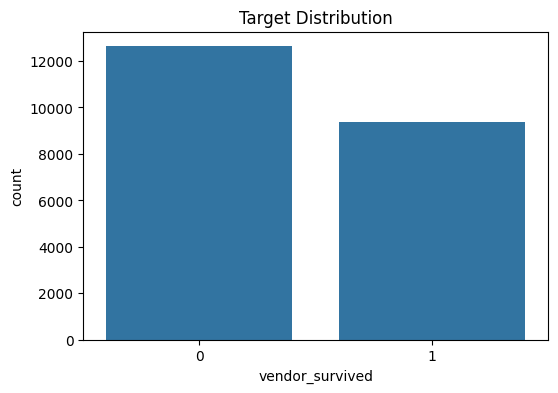

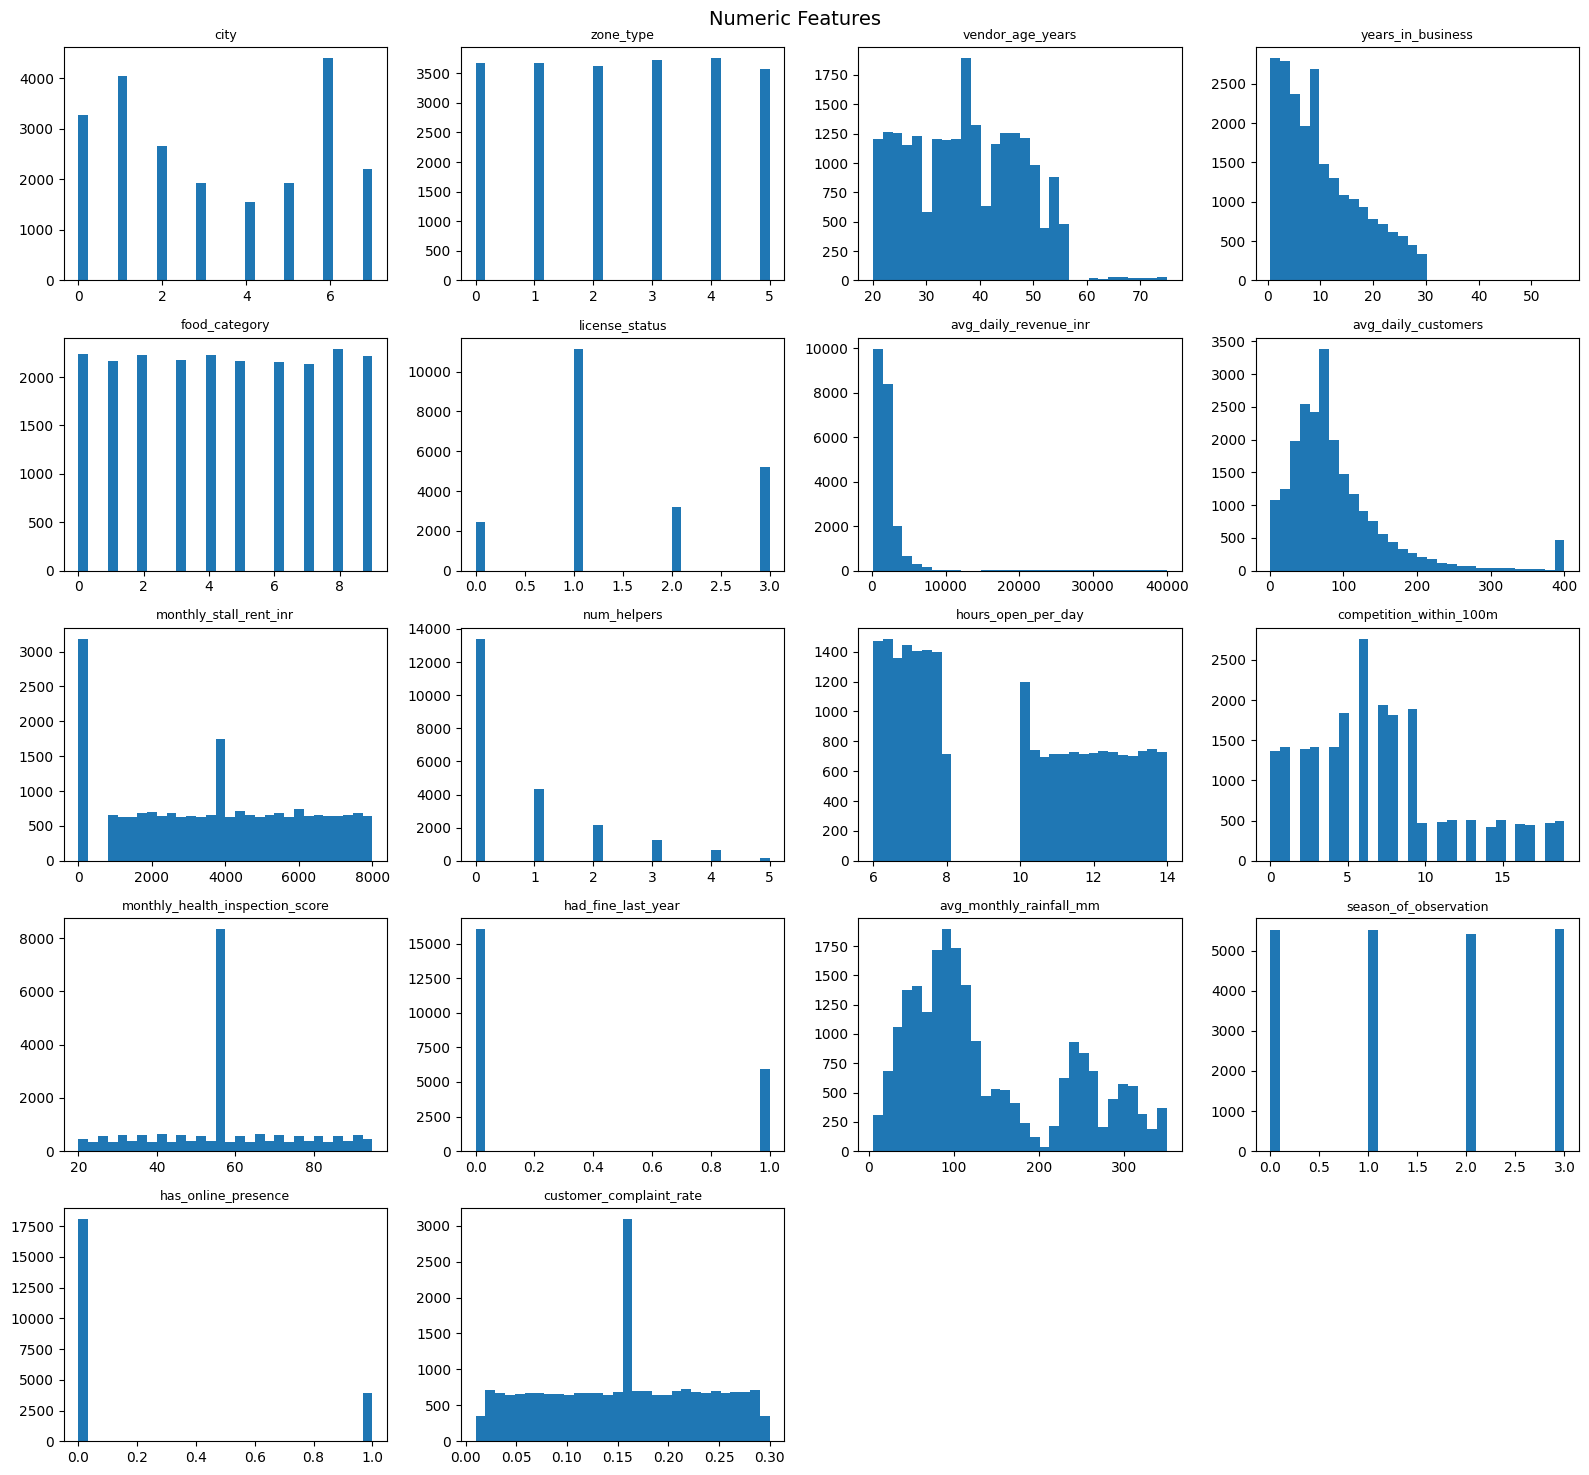

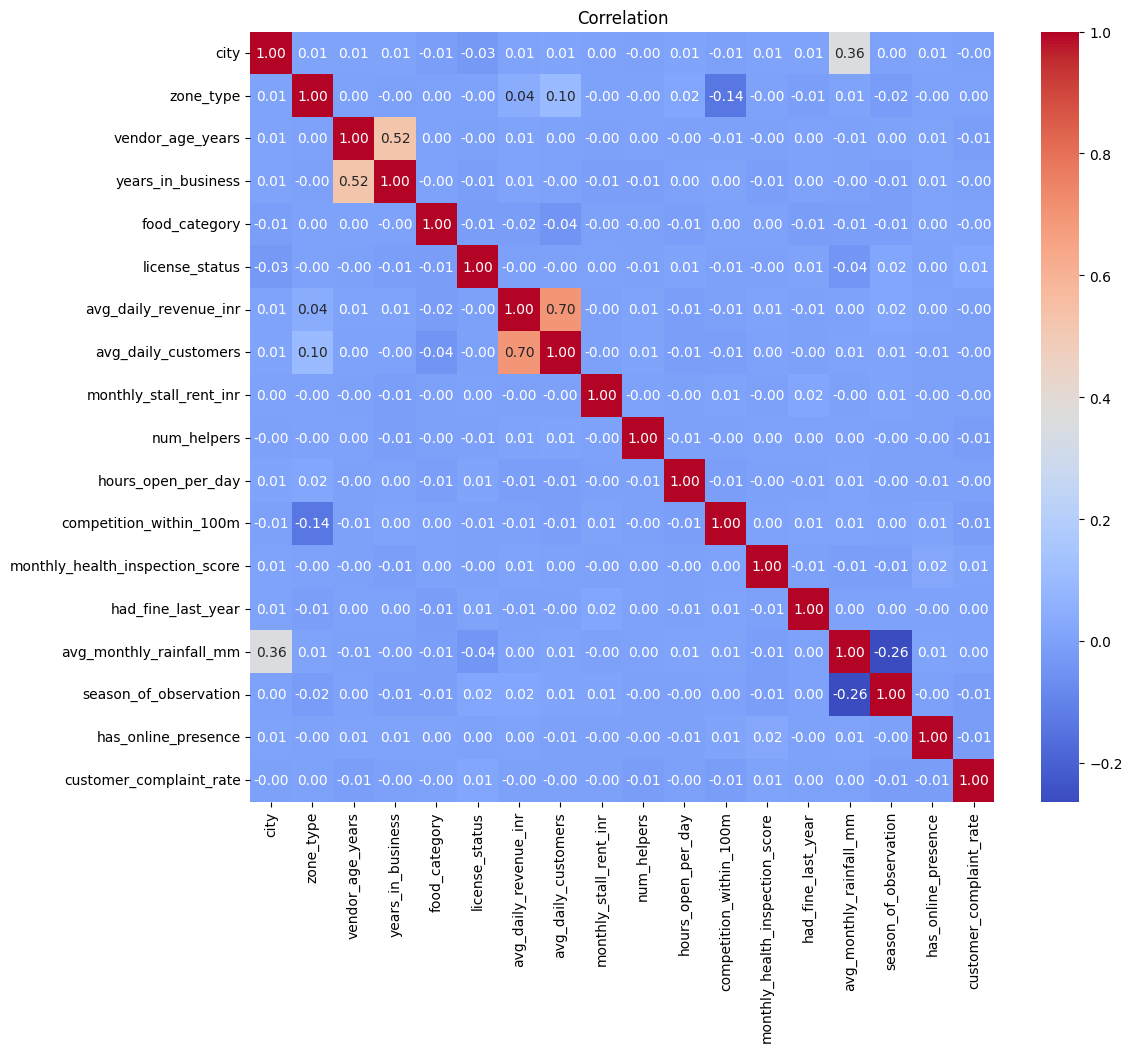

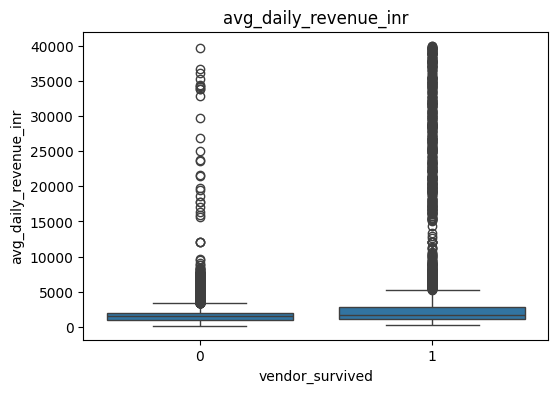

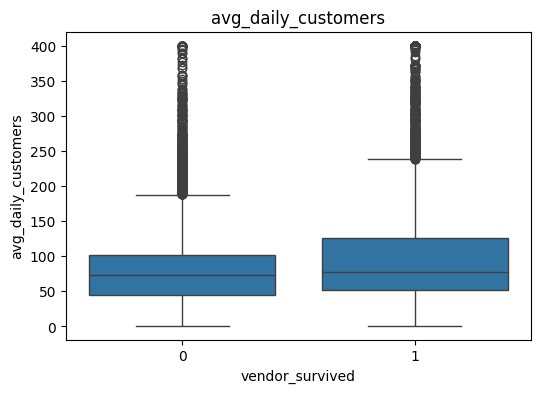

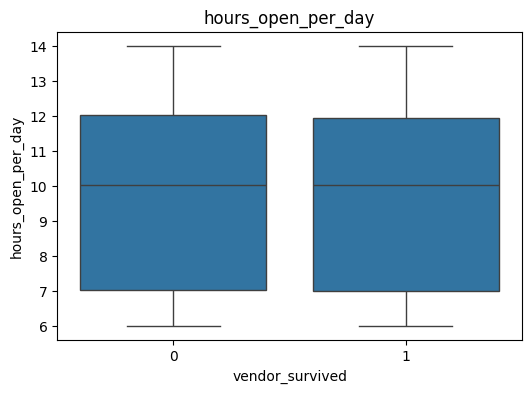

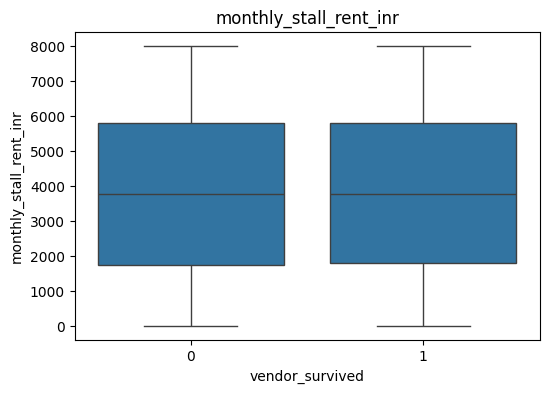

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

output_dir = "output_visualizations"
os.makedirs(output_dir, exist_ok=True)

def load_data(path):
    df = pd.read_csv(path)
    cat = df.select_dtypes(include=['object']).columns.drop('vendor_id')
    num = df.select_dtypes(include=['float64','int64']).columns
    df[cat] = df[cat].apply(lambda x: x.fillna(x.mode()[0]))
    df[num] = df[num].apply(lambda x: x.fillna(x.median()))
    le = LabelEncoder()
    for c in cat:
        df[c] = le.fit_transform(df[c])
    X = df.drop(columns=['vendor_id','vendor_survived'])
    y = df['vendor_survived']
    return df, X, y

def save_show(fig, name):
    fig.savefig(os.path.join(output_dir, f"{name}.png"), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

def visualize(df, X, y):
    fig = plt.figure(figsize=(6,4))
    sns.countplot(x=y)
    plt.title("Target Distribution")
    save_show(fig, "target")

    num = X.select_dtypes(include=np.number).columns
    n = len(num)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    ax = ax.flatten()
    for i, c in enumerate(num):
        ax[i].hist(X[c], bins=30)
        ax[i].set_title(c, fontsize=9)
    for j in range(i+1, len(ax)):
        fig.delaxes(ax[j])
    fig.suptitle("Numeric Features", fontsize=14)
    plt.tight_layout()
    save_show(fig, "hist")

    fig = plt.figure(figsize=(12,10))
    sns.heatmap(X[num].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation")
    save_show(fig, "corr")

    cols_check = ['avg_daily_revenue_inr','avg_daily_customers','hours_open_per_day','monthly_stall_rent_inr']
    for c in cols_check:
        if c in X.columns:
            fig = plt.figure(figsize=(6,4))
            sns.boxplot(x=y, y=X[c])
            plt.title(c)
            save_show(fig, f"box_{c}")

def split_scale(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    sm = SMOTE(random_state=42)
    Xtr, ytr = sm.fit_resample(Xtr, ytr)
    return Xtr, Xte, ytr, yte

def models():
    return {
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
        "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=200, random_state=42),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(probability=True, random_state=42),
        "LogReg": LogisticRegression(max_iter=500),
        "NaiveBayes": GaussianNB(),
        "XGBoost": XGBClassifier(eval_metric='logloss', n_estimators=200, random_state=42)
    }

def evaluate(mdict, Xtr, ytr, Xte, yte):
    res = []
    for n, m in mdict.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)
        res.append([n,
                    accuracy_score(yte,p),
                    precision_score(yte,p),
                    recall_score(yte,p),
                    f1_score(yte,p)])
    df = pd.DataFrame(res, columns=["Model","Accuracy","Precision","Recall","F1"])
    return df.sort_values("F1", ascending=False)

def plot_results(df):
    fig = plt.figure(figsize=(10,6))
    sns.barplot(x="F1", y="Model", data=df, hue="Model", legend=False, palette="tab20")
    plt.title("F1 Score")
    save_show(fig, "f1")

    fig = plt.figure(figsize=(10,6))
    sns.barplot(x="Accuracy", y="Model", data=df, hue="Model", legend=False, palette="tab20c")
    plt.title("Accuracy")
    save_show(fig, "acc")

path = r"D:\Data-Science-Internship-Tasks-projects\archive (1)\urban_street_food_vendor_survival_dataset.csv"

df, X, y = load_data(path)
visualize(df, X, y)
Xtr, Xte, ytr, yte = split_scale(X, y)
mdict = models()
res = evaluate(mdict, Xtr, ytr, Xte, yte)
display(res)
plot_results(res)
best_name = res.iloc[0]["Model"]
best_model = mdict[best_name]
pred = best_model.predict(Xte)
print(best_name)
print(classification_report(yte, pred))

In [ ]:
print("Project 2: Urban Street Food Vendor Survival complete")